[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/08_ai_engineering/A2_vector_stores_survey.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A2 — Vector-Store Landscape

> **Module:** AI Engineering · **Type:** Appendix · **Estimated time:** 45–60 min · **Difficulty:** Intermediate

Notebook 29 (`29_embeddings_retrieval.ipynb`) showed you the *idea* behind a vector store with a hand-rolled NumPy matrix and a cosine-similarity loop. That is exactly how a real vector database works — but at production scale you'd hit three limits fast:

1. **Latency.** A linear scan over a million vectors takes seconds, not milliseconds.
2. **Memory.** A million vectors of dimension 768 in float32 is already ≈ 3 GB — and you also want metadata, payload, and a backup.
3. **Operability.** You want incremental upserts, deletes, multi-tenant filters, snapshots, replication.

This appendix surveys the popular **vector stores** (FAISS, Chroma, Qdrant, Weaviate, Pinecone, pgvector, Milvus) and the **higher-level RAG/agent frameworks** (LangChain, LlamaIndex, Haystack) — and gives you a decision rubric so you know which to reach for when.

---

## 🎯 Learning objectives

By the end of this notebook you'll be able to:
- Explain what a *vector index* does on top of plain cosine similarity.
- Pick a vector store using a 4-question rubric (scale, hosting, filtering, ecosystem).
- Run a FAISS index hands-on and read the equivalent code for Chroma, Qdrant, and pgvector.
- Read framework code without panicking: what LangChain's `VectorStoreRetriever` actually wraps.

## ✅ Prerequisites
- Notebook 29 (embeddings + cosine similarity).
- Familiarity with class-based APIs.


## 1. The vector-index problem in one paragraph

A *vector store* = embeddings index + metadata store + query API. The interesting bit is the **index structure** — without one, every query is a full scan. The two most common index families:

| Family | Idea | Trade-off |
|---|---|---|
| **Tree / IVF** (inverted file) | Cluster the vectors. At query time, only search the closest clusters. | Fast, slight recall loss. |
| **Graph** (HNSW) | Build a small-world graph between nearby vectors. Walk the graph greedily. | Very fast and high recall; more memory. |
| **PQ** (product quantization) | Compress each vector into a few bytes. | 10–100× smaller; some accuracy loss. |

Real systems combine these (e.g. `IVF-PQ` in FAISS, HNSW with quantization in Qdrant). For *learning purposes* you don't need to understand the internals — you just need to know that the **first knob** every store exposes is the index type, and the **second knob** is `k` (top-K neighbours).


## 2. Setup — shared embedding function

We'll reuse the course's `MockEmbedder` (deterministic hash-based vectors) so the notebook runs offline. Swap in `OpenAIEmbedder` or `LocalEmbedder` one-line later — see Notebook A1.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Make the repo-root llm_providers.py importable regardless of which folder
# Jupyter launched the kernel in (it lives at the course root).
import sys, pathlib
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "llm_providers.py").exists()), None)
if _root:                       # local checkout — use the repo's module
    sys.path.insert(0, str(_root))
else:                           # Colab / standalone — fetch it next to the notebook
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/ChrisW09/Python-for-AI-Driven-Automation"
        "/main/llm_providers.py", "llm_providers.py")

from llm_providers import MockEmbedder

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

embedder = MockEmbedder(dim=128)

# A tiny corpus — eight FAQ documents to retrieve from
DOCS = [
    ("billing-1",  "How do I update my payment method?"),
    ("billing-2",  "When does my subscription renew?"),
    ("billing-3",  "Can I get a refund for an unused month?"),
    ("account-1",  "How do I reset my password?"),
    ("account-2",  "How do I change my email address?"),
    ("product-1",  "How do I export my data as CSV?"),
    ("product-2",  "Where can I see usage statistics?"),
    ("support-1",  "How do I contact a human support agent?"),
]
ids, texts = zip(*DOCS)
print(f"{len(texts)} docs · embedding dim = {embedder.dim}")


8 docs · embedding dim = 128


In [2]:
# Compute embeddings once. (In a real system you persist them in the store.)
doc_vectors = embedder.embed(list(texts))                  # (N, dim), L2-normalised
print("doc_vectors shape:", doc_vectors.shape)

QUERY = "I want my money back"
query_vec = embedder.embed([QUERY])[0]                    # (dim,)
print("query_vec shape  :", query_vec.shape)


doc_vectors shape: (8, 128)
query_vec shape  : (128,)


## 3. Baseline — full scan (what Notebook 29 did)

To anchor the comparison, here's the brute-force version. It returns the *exact* nearest neighbours. Every fancier index is benchmarked against it.


In [3]:
def brute_search(query_vec, doc_vectors, ids, k=3):
    # cosine sim = dot product (vectors are normalised by the embedder)
    sims = doc_vectors @ query_vec
    order = np.argsort(-sims)[:k]
    return [(ids[i], float(sims[i])) for i in order]

print("Brute-force top-3 for:", repr(QUERY))
for doc_id, score in brute_search(query_vec, doc_vectors, ids):
    print(f"  {score:+.4f}  {doc_id}")


Brute-force top-3 for: 'I want my money back'
  +0.3973  billing-1
  +0.3461  account-2
  +0.3116  account-1


---

### ✋ Quick exercise (~2 min) — Retrieve the single best FAQ

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A customer types *"How can I see how much I've used this month?"*. Using only the tools from §2–§3, embed that query and use `brute_search` to return the **top-1** matching FAQ id and its cosine score.

```python
new_query = "How can I see how much I've used this month?"
```

In [4]:
# ✍️ Your turn 👇
new_query = "How can I see how much I've used this month?"
# 1. embed new_query with `embedder` (remember embed() takes a *list*)
# 2. pass the resulting vector to brute_search to get the single best FAQ (k=1)

<details>
<summary>✅ <b>Solution</b></summary>

```python
qv = embedder.embed([new_query])[0]
print(brute_search(qv, doc_vectors, ids, k=1))
```

`embedder.embed` takes a list and returns an `(N, dim)` array, so we grab row `0`. `brute_search` then ranks every doc by cosine similarity (= dot product, since the embedder L2-normalises) and returns the single best match — here `support-1`. (With `MockEmbedder`'s hash-based vectors the top hit isn't semantically meaningful; a real embedder would surface the usage-statistics FAQ.)
</details>

## 4. FAISS — the workhorse local index

[**FAISS**](https://github.com/facebookresearch/faiss) (Facebook AI Similarity Search) is the most-used embedded vector library. It runs in your process, supports many index types, and is what most other stores use under the hood.

```bash
pip install faiss-cpu                # CPU build, MIT-licensed, no GPU needed
```

Below is the **standard FAISS pattern** — written as *reference code* so the notebook still runs without faiss installed. Uncomment after `pip install`.


In [5]:
# ── FAISS reference code ─────────────────────────────────────────────────
# import faiss
#
# d = doc_vectors.shape[1]
#
# # (a) Flat index — exact search, identical to brute force, but in optimised C++.
# index_flat = faiss.IndexFlatIP(d)        # IP = inner product (cosine when normalised)
# index_flat.add(doc_vectors.astype("float32"))
#
# D, I = index_flat.search(query_vec.reshape(1, -1).astype("float32"), k=3)
# print("FAISS Flat top-3:", [(ids[i], float(s)) for s, i in zip(D[0], I[0])])
#
# # (b) HNSW index — graph-based, sub-linear search, ~100× faster on 1M+ vectors.
# index_hnsw = faiss.IndexHNSWFlat(d, 32)      # 32 = M, neighbours per node (positional — faiss's SWIG API takes no kwargs)
# index_hnsw.hnsw.efConstruction = 200      # build-time recall knob
# index_hnsw.hnsw.efSearch       = 64       # query-time recall knob
# index_hnsw.add(doc_vectors.astype("float32"))
# D, I = index_hnsw.search(query_vec.reshape(1, -1).astype("float32"), k=3)
# print("FAISS HNSW top-3:", [(ids[i], float(s)) for s, i in zip(D[0], I[0])])

# Tiny pure-NumPy stand-in so the cell still emits a comparable result offline:
def faiss_like_flat(query, vectors, k=3):
    D = vectors @ query
    I = np.argsort(-D)[:k]
    return D[I], I

D, I = faiss_like_flat(query_vec, doc_vectors)
print("[offline stand-in] top-3:", [(ids[i], float(D[j])) for j, i in enumerate(I)])


[offline stand-in] top-3: [('billing-1', 0.3973303735256195), ('account-2', 0.34610188007354736), ('account-1', 0.3116138279438019)]


### When FAISS is the right call
- You want the **fastest** in-process search and don't need a network service.
- The dataset fits in RAM (or you're happy to manage sharding yourself).
- You want maximum index-type flexibility (`IndexFlat`, `IndexIVFFlat`, `IndexHNSW`, `IndexIVFPQ`…).
- You're prototyping or building a desktop app.

### When FAISS is *not* enough
- Multi-process write access (no built-in concurrency control).
- Rich metadata filtering (`WHERE tenant_id = ... AND ts > ...`).
- Long-term persistence with replication, snapshots, ACLs.


### 🔬 What actually happens when HNSW *walks the graph*?

Section 1's table told you HNSW is "sub-linear" — it touches a few *hundred* nodes, never all *n*. But *how*? "Walk a small-world graph greedily" is a one-liner that hides the actual mechanic. The §3 baseline showed the brute-force *full scan* this replaces; here we open the box on the **graph traversal itself** — the move FAISS's `IndexHNSWFlat` and pgvector's `hnsw` index make on every query, and what the `efSearch` knob in §4 actually controls.

**The idea: each vector is a node; edges connect it to a handful of its nearest neighbours.** To find the node closest to a query `q` you don't scan everything — you *navigate*:

```text
  start at an entry node
        │
        ▼
   look at my neighbours ──► is any neighbour closer to q than I am?
        │                          │ yes                    │ no
        │                          ▼                        ▼
        └────── hop to the closest neighbour          STOP — I'm a
                (repeat from there)                    local nearest node
```

That's **greedy best-first search**: at each step move to whichever neighbour is closest to `q`, stop when none improves. On a *properly layered* HNSW graph each hop roughly halves the remaining distance, so you arrive in about **O(log n)** hops — touching a tiny fraction of the nodes. (The single-layer toy below shows the greedy walk itself; the true logarithmic scaling needs HNSW's multi-layer "highway" structure on top of it.) The cell below builds a small graph and runs exactly this walk, offline.

In [6]:
import numpy as np

# --- Build a tiny navigable graph offline: 400 random 2-D points, ---
# --- each linked to its M nearest neighbours (a 1-layer HNSW-style graph). ---
rng = np.random.default_rng(7)
N, DIM, M = 400, 2, 12                      # 400 nodes, 2-D so we can reason, 12 edges each
pts = rng.standard_normal((N, DIM))

dist = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)   # (N, N) euclidean
neighbours = [list(np.argsort(d)[1:M+1]) for d in dist]            # M nearest, skip self

def greedy_search(query, entry=0):
    """Plain greedy walk: hop to the single closest neighbour until none is closer."""
    cur = entry
    cur_d = np.linalg.norm(pts[cur] - query)
    path, touched = [cur], set(neighbours[cur]) | {cur}
    while True:
        nbr = [(np.linalg.norm(pts[j] - query), j) for j in neighbours[cur]]
        best_d, best_j = min(nbr)
        if best_d >= cur_d:                 # no neighbour improves -> stop
            break
        cur, cur_d = best_j, best_d
        path.append(cur); touched |= set(neighbours[cur]) | {cur}
    return cur, path, touched

query = np.array([1.6, -1.7])              # a query off in a corner
found, path, touched = greedy_search(query, entry=0)
true_nearest = int(np.argmin(np.linalg.norm(pts - query, axis=1)))   # brute-force truth

print(f"hop path        : {[int(n) for n in path]}")
print(f"hops taken      : {len(path) - 1}")
print(f"found node      : {found}   (greedy result)")
print(f"true nearest    : {true_nearest}   (brute force over all {N})")
print(f"exact match?    : {found == true_nearest}")
print(f"nodes examined  : {len(touched)} of {N}  "
      f"({100*len(touched)/N:.0f}% — the rest were never touched)")

hop path        : [0, 20, 179, 176, 298, 323, 338, 228, 249, 319, 389]
hops taken      : 10
found node      : 389   (greedy result)
true nearest    : 389   (brute force over all 400)
exact match?    : True
nodes examined  : 69 of 400  (17% — the rest were never touched)


Whatever the match result above, notice the headline: the walk examined only a *fraction* of the 400 nodes — most were never looked at. That is HNSW's whole performance story: **navigate, don't scan.**

But pure greedy has a failure mode. It keeps a *single* best node, so it can get **stuck in a local minimum** — a node whose neighbours are all farther from `q`, even though a better node sits one street over. Real HNSW fixes this by keeping a **candidate list of width `efSearch`** instead of one best: it explores the `ef` most promising frontiers in parallel, so a single bad junction no longer dead-ends the search. Below we run the *same* graph with a width-`ef` beam and watch recall climb as we widen it — this is the exact `efSearch` knob from the FAISS code in §4 (`index_hnsw.hnsw.efSearch = 64`).

In [7]:
import heapq

def beam_search(query, entry=0, ef=1):
    """HNSW-style search: keep the `ef` best candidates, expand the frontier from them.
    ef=1 reduces to plain greedy; larger ef explores more routes -> higher recall."""
    d0 = float(np.linalg.norm(pts[entry] - query))
    visited = {entry}
    frontier = [(d0, entry)]                 # min-heap of nodes still to expand
    best = [(d0, entry)]                      # `ef` closest seen so far
    while frontier:
        d_c, c = heapq.heappop(frontier)
        if d_c > max(best)[0] and len(best) >= ef:
            break                             # nothing left can beat our current best set
        for j in neighbours[c]:
            if j in visited:
                continue
            visited.add(j)
            dj = float(np.linalg.norm(pts[j] - query))
            heapq.heappush(frontier, (dj, j))
            best.append((dj, j))
            best = sorted(best)[:ef]          # keep only the ef closest
    return best[0][1], len(visited)            # nearest found, nodes examined

# Sweep ef over 300 random queries; measure recall@1 vs the brute-force truth + work done.
rq = np.random.default_rng(123)
Q = rq.standard_normal((300, DIM)) * 1.2
truth = np.argmin(np.linalg.norm(Q[:, None, :] - pts[None, :, :], axis=2), axis=1)

print(f"{'efSearch':>8} | {'recall@1':>9} | {'avg nodes examined':>19}")
print('-' * 44)
for ef in (1, 2, 4, 8, 16):
    hits = work = 0
    for q, t in zip(Q, truth):
        found, examined = beam_search(q, entry=0, ef=ef)
        hits += (found == t); work += examined
    print(f"{ef:>8} | {hits/len(Q):>9.3f} | {work/len(Q):>19.1f}  (of {N})")

efSearch |  recall@1 |  avg nodes examined
--------------------------------------------
       1 |     0.863 |                49.7  (of 400)
       2 |     0.900 |                52.4  (of 400)
       4 |     0.963 |                56.9  (of 400)
       8 |     0.997 |                62.5  (of 400)
      16 |     0.997 |                71.7  (of 400)


Read the table top to bottom: at `efSearch=1` (pure greedy) recall is good but not perfect — those misses are the local minima. Widen the beam and **recall climbs toward 1.0**, paying for it with *more nodes examined per query*. That is the entire ANN trade-off made concrete on the graph itself: `efSearch` lets you **buy recall with work**, and even at the widest setting you still examine only a fraction of all `N` vectors.

> 🧠 **Mental model.** An HNSW index is a *road map* between similar vectors. A query is a destination; the search is a greedy drive that takes the closest-looking turn at each junction. `efSearch` is how many parallel routes you're willing to try at once — one route is fast but can dead-end (local minimum); a handful of routes almost always finds the true-nearest, for a little more driving.

> ⚠️ **Why the toy looks easy but production isn't.** Here the graph is tiny and 2-D, so even a modest beam hits ~100% recall. At a million 768-dim vectors the layered graph (a sparse "highway" top layer not modelled here) plus an `efSearch` candidate list is what holds recall near ~99% — and that lost ~1% is precisely the *approximate* in *approximate nearest neighbour*. Tune `efSearch`/`efConstruction` up when you need recall, down when you need latency.

## 5. Chroma — the simplest hosted-or-embedded option

[**Chroma**](https://www.trychroma.com/) is an open-source vector database with a clean Python API. It can run **in-process** (file-backed) or as a server.

```bash
pip install chromadb
```

The killer feature: it stores **embeddings + documents + metadata** in one place. You can filter by metadata at query time.


In [8]:
# ── Chroma reference code (file-backed, no server) ───────────────────────
# import chromadb
# from chromadb.config import Settings
#
# client = chromadb.PersistentClient(path="./.chroma_demo")
# col = client.get_or_create_collection("faq", metadata={"hnsw:space": "cosine"})
#
# col.upsert(
#     ids=list(ids),
#     embeddings=doc_vectors.tolist(),
#     documents=list(texts),
#     metadatas=[{"category": i.split("-")[0]} for i in ids],
# )
#
# res = col.query(
#     query_embeddings=[query_vec.tolist()],
#     n_results=3,
#     where={"category": "billing"},      # ← metadata filter
# )
# print(res["ids"][0], res["distances"][0])

# Offline stand-in showing the same metadata-filter pattern in pure NumPy:
def filtered_search(query, vectors, ids, where=None, k=3):
    mask = np.ones(len(ids), dtype=bool)
    if where:
        for key, val in where.items():
            if key == "category":
                mask &= np.array([i.split("-")[0] == val for i in ids])
    sub_v = vectors[mask]; sub_ids = [ids[i] for i, ok in enumerate(mask) if ok]
    sims = sub_v @ query
    order = np.argsort(-sims)[:k]
    return [(sub_ids[i], float(sims[i])) for i in order]

print("Filtered (category=billing):")
for r in filtered_search(query_vec, doc_vectors, list(ids), where={"category":"billing"}):
    print(" ", r)


Filtered (category=billing):
  ('billing-1', 0.3973303735256195)
  ('billing-2', 0.12646280229091644)
  ('billing-3', -0.020695719867944717)


---

### ✋ Quick exercise (~2 min) — Metadata-filtered retrieval

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The billing team's assistant must only surface **billing** FAQs. Reuse `filtered_search` from §5: embed the query *"I want to cancel and get a refund"* and return the **top-2** results restricted to `category="billing"`.

In [9]:
# ✍️ Your turn 👇
# Embed the query "I want to cancel and get a refund", then use filtered_search (from §5)
# with where={"category": "billing"} to return the top-2 billing FAQs.

<details>
<summary>✅ <b>Solution</b></summary>

```python
q = embedder.embed(["I want to cancel and get a refund"])[0]
for hit in filtered_search(q, doc_vectors, list(ids), where={"category": "billing"}, k=2):
    print(hit)
```

`filtered_search` applies the `where` mask *before* ranking, so only the three `billing-*` docs compete — exactly how Chroma's `where=` and Qdrant's `query_filter` push the filter into the query rather than slicing after top-K.
</details>

## 6. Qdrant — the production-flavoured option

[**Qdrant**](https://qdrant.tech/) is open source + cloud, written in Rust, with rich filtering (`must`, `should`, `must_not`), HNSW + quantization, and a smooth Python client. The same code talks to:
- an **in-process** test client,
- a local **Docker** container,
- a **Qdrant Cloud** managed cluster.

```bash
pip install qdrant-client
# optionally:  docker run -p 6333:6333 qdrant/qdrant
```


In [10]:
# ── Qdrant reference code (in-memory client; no server needed) ───────────
# from qdrant_client import QdrantClient
# from qdrant_client.models import VectorParams, Distance, PointStruct, Filter, FieldCondition, MatchValue
#
# client = QdrantClient(":memory:")               # in-process for tests
# # client = QdrantClient(host="localhost", port=6333)        # local Docker
# # client = QdrantClient(url="https://YOUR-CLUSTER.qdrant.io", api_key="...")   # cloud
#
# client.recreate_collection(
#     collection_name="faq",
#     vectors_config=VectorParams(size=doc_vectors.shape[1], distance=Distance.COSINE),
# )
# client.upsert("faq", points=[
#     PointStruct(id=i, vector=v.tolist(), payload={"text": t, "cat": t_id.split("-")[0]})
#     for i, (t_id, t, v) in enumerate(zip(ids, texts, doc_vectors))
# ])
#
# hits = client.search(
#     collection_name="faq",
#     query_vector=query_vec.tolist(),
#     query_filter=Filter(must=[FieldCondition(key="cat", match=MatchValue(value="billing"))]),
#     limit=3,
# )
# for h in hits:
#     print(h.score, h.payload["text"])
print("Qdrant call structure shown above; behaviour is identical to the offline stand-in in §5.")


Qdrant call structure shown above; behaviour is identical to the offline stand-in in §5.


## 7. Weaviate, Pinecone, Milvus — the rest of the field

You'll meet these names in production stacks. The mental model is the same — collection → upsert → query — but the trade-offs differ.

| Store | Hosting | Strengths | Watch out for |
|---|---|---|---|
| **Weaviate** | OSS + cloud | Built-in vectorisers (text2vec modules), GraphQL API, hybrid (BM25 + vector) search out of the box | Heavier to operate; module pinning |
| **Pinecone** | Cloud-only (managed SaaS) | Zero ops, autoscaling, namespaces for multi-tenancy | Lock-in; per-vector pricing |
| **Milvus / Zilliz** | OSS + cloud (Zilliz) | Petabyte scale, GPU-accelerated, many index types | Operational footprint; learning curve |

```python
# Pinecone (very brief — cloud only)
# from pinecone import Pinecone
# pc = Pinecone(api_key="...")
# idx = pc.Index("faq")
# idx.upsert(vectors=[(id_, v.tolist(), {"text": t}) for id_, v, t in zip(ids, doc_vectors, texts)])
# res = idx.query(vector=query_vec.tolist(), top_k=3, include_metadata=True)
```

```python
# Weaviate (very brief — needs running server or WCS)
# import weaviate
# client = weaviate.connect_to_local()
# col = client.collections.create("Faq", vectorizer_config=None)   # we supply vectors
# col.data.insert_many([{"text": t, "_vector": v.tolist()} for t, v in zip(texts, doc_vectors)])
# res = col.query.near_vector(near_vector=query_vec.tolist(), limit=3)
```


## 8. pgvector — the boring-good choice when you already have Postgres

[**pgvector**](https://github.com/pgvector/pgvector) turns Postgres into a vector store. If you *already run Postgres* and don't want another moving part, this is often the right answer for up to a few million vectors.

```sql
-- Inside any Postgres 11+ database:
CREATE EXTENSION IF NOT EXISTS vector;

CREATE TABLE faq (
    id    TEXT PRIMARY KEY,
    text  TEXT,
    cat   TEXT,
    embedding vector(128)             -- match your model's dimension
);

-- HNSW index (pgvector ≥ 0.5; works on any Postgres version pgvector supports)
CREATE INDEX ON faq USING hnsw (embedding vector_cosine_ops);
```

```python
# Python side (psycopg + pgvector adapter)
# import psycopg, pgvector.psycopg
# conn = psycopg.connect("postgresql://localhost/mydb")
# pgvector.psycopg.register_vector(conn)
# with conn.cursor() as cur:
#     cur.executemany(
#         "INSERT INTO faq (id, text, cat, embedding) VALUES (%s, %s, %s, %s) "
#         "ON CONFLICT (id) DO UPDATE SET embedding = EXCLUDED.embedding",
#         [(i, t, i.split("-")[0], v) for i, t, v in zip(ids, texts, doc_vectors)],
#     )
#     cur.execute(
#         "SELECT id, text, 1 - (embedding <=> %s) AS score "
#         "FROM faq WHERE cat = %s "
#         "ORDER BY embedding <=> %s LIMIT 3",
#         (query_vec, "billing", query_vec),
#     )
#     for row in cur.fetchall(): print(row)
```

When pgvector is the right call:
- You already operate Postgres in production.
- < ~10 M vectors with HNSW, < ~50 M with IVFFlat.
- You want **joins** between vector results and relational data without ETL.


## 9. Decision rubric — pick a store in four questions

```
1. Do I just need an index inside my app process?
   YES → FAISS
   NO  → continue

2. Do I already run Postgres and have < ~10M vectors?
   YES → pgvector
   NO  → continue

3. Do I want zero-ops managed (and tolerate cloud lock-in)?
   YES → Pinecone   (or Qdrant Cloud / Weaviate Cloud)
   NO  → continue

4. I want OSS, self-host, rich filters →  Qdrant  (or Weaviate, or Milvus at huge scale)
```

A second tie-breaker most teams ignore until it bites them: **payload filtering richness.** If your retrieval needs `WHERE tenant_id = ? AND lang = 'de' AND ts > ...` you want a store that pushes those filters into the index (Qdrant, Weaviate, pgvector). Doing it after the top-K causes recall collapse.


---

### ✋ Quick exercise (~2 min) — Pick the store from the constraints

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Turn the §9 rubric into a tiny `pick_store(in_process, has_postgres, n_vectors, want_managed)` function and use it to answer: (a) a desktop app needing an in-process index, (b) a team already running Postgres with ~2M vectors, (c) a startup wanting zero-ops managed hosting at ~8M vectors.

In [11]:
# ✍️ Your turn 👇
# Encode the §9 rubric as a function and check it on the three scenarios below.
def pick_store(in_process, has_postgres, n_vectors, want_managed):
    ...  # walk the four questions in order, return the store name

# print(pick_store(in_process=True,  has_postgres=False, n_vectors=50_000,    want_managed=False))
# print(pick_store(in_process=False, has_postgres=True,  n_vectors=2_000_000, want_managed=False))
# print(pick_store(in_process=False, has_postgres=False, n_vectors=8_000_000, want_managed=True))

<details>
<summary>✅ <b>Solution</b></summary>

```python
def pick_store(in_process, has_postgres, n_vectors, want_managed):
    if in_process:
        return "FAISS"
    if has_postgres and n_vectors < 10_000_000:
        return "pgvector"
    if want_managed:
        return "Pinecone"          # or Qdrant Cloud / Weaviate Cloud
    return "Qdrant"                # OSS, self-host, rich filters

print(pick_store(in_process=True,  has_postgres=False, n_vectors=50_000,    want_managed=False))  # FAISS
print(pick_store(in_process=False, has_postgres=True,  n_vectors=2_000_000, want_managed=False))  # pgvector
print(pick_store(in_process=False, has_postgres=False, n_vectors=8_000_000, want_managed=True))   # Pinecone
```

The function walks the four rubric questions **in order** — the first matching constraint wins, which is exactly how the §9 decision tree is meant to be read.
</details>

## 10. Higher-level frameworks — LangChain / LlamaIndex / Haystack

The libraries above are *vector stores*. The libraries below are **RAG/agent orchestration frameworks** that wrap them (plus prompt templating, loaders, evaluators, tracing). The right tool depends on what you want to outsource.

| Framework | Best for | Watch out for |
|---|---|---|
| **LangChain** | Composing chains/agents; huge ecosystem of integrations | API churn between versions; abstraction overhead for simple cases |
| **LlamaIndex** | Document ingestion & advanced retrievers (hybrid, fusion, hierarchical) | Different agent model (`Workflow`-based); less integrated than LangChain |
| **Haystack 2** | Production pipelines with strong typing & deployment story | Smaller community than the two above |
| **DSPy** | Programmatic prompt optimisation (treat prompts as parameters) | Different mental model; not a drop-in replacement |
| **smolagents (HuggingFace)** | Minimal tool-using agents in pure Python | Newer; not yet a full RAG framework |

A LangChain `RetrievalQA` chain in 6 lines:

```python
# pip install langchain langchain-community langchain-openai chromadb
# from langchain_community.vectorstores import Chroma   # post-1.0: provider packages,
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings  # not langchain core
# from langchain.chains import RetrievalQA
#
# vs = Chroma.from_texts(list(texts), embedding=OpenAIEmbeddings(), metadatas=[{"id": i} for i in ids])
# qa = RetrievalQA.from_chain_type(llm=ChatOpenAI(model="gpt-5.4-mini"),
#                                  retriever=vs.as_retriever(search_kwargs={"k": 3}))
# print(qa.run("Can I cancel and get a refund?"))
```

**Course philosophy.** Notebook 29 implements RAG by hand so you understand what's happening. Reach for a framework once your real pipeline outgrows ~200 lines — not before.


## 🧪 Exercises

### Exercise 1 — Add metadata filtering to the FAISS stand-in
Extend the brute-force search in §3 to accept a `where: dict` argument and apply it *before* the top-K — exactly like Chroma's `where=` and Qdrant's `query_filter`. Measure the recall change vs unfiltered when the filter excludes the true top result.


In [12]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
def search_with_filter(query, vectors, ids, where=None, k=3):
    mask = np.ones(len(ids), dtype=bool)
    if where and "category" in where:
        mask &= np.array([i.split("-")[0] == where["category"] for i in ids])
    sub_v   = vectors[mask]
    sub_ids = [ids[i] for i, ok in enumerate(mask) if ok]
    if len(sub_ids) == 0:
        return []
    sims  = sub_v @ query
    order = np.argsort(-sims)[: min(k, len(sub_ids))]
    return [(sub_ids[i], float(sims[i])) for i in order]

print("All categories       :", search_with_filter(query_vec, doc_vectors, list(ids)))
print("WHERE category=account:", search_with_filter(query_vec, doc_vectors, list(ids),
                                                    where={"category":"account"}))


All categories       : [('billing-1', 0.3973303735256195), ('account-2', 0.34610188007354736), ('account-1', 0.3116138279438019)]
WHERE category=account: [('account-2', 0.34610188007354736), ('account-1', 0.3116138279438019)]


### Exercise 2 — Measure recall vs k
Careful with the setup: recall@k compares **two different rankings**, so scoring exact search against *its own* top-1 would give a flat 1.0 at every k — a plot that can't tell you anything. Do what real vector-store benchmarks do instead: make each query a **noisy copy of one document's vector** (that source doc is the ground truth), then compute recall@k for k = 1, 2, 3, 5 across 50 queries and plot it. You should see the canonical climbing curve — larger k buys back the hits that noise pushed out of the top spot.


recall@k: {1: 0.62, 2: 0.82, 3: 0.9, 5: 0.98}


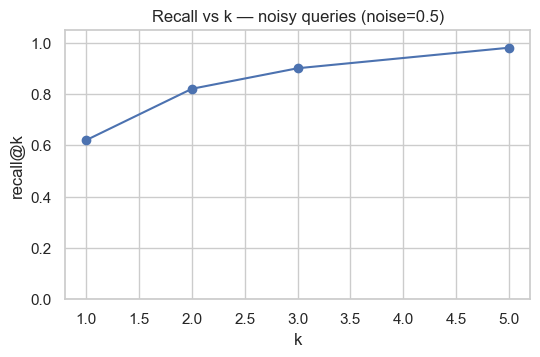

In [13]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
# Recall@k compares TWO rankings — exact search scored against its own top-1
# is 1.0 at every k by definition. So each query is a NOISY copy of one doc:
# the source doc is the ground truth, and recall@k measures how often it
# survives in the top-k as the query drifts away from it.
rng = np.random.default_rng(0)
N_QUERIES = 50
NOISE = 0.5                     # drift: big enough that the top spot is no longer guaranteed

recalls = {k: [] for k in (1, 2, 3, 5)}
for _ in range(N_QUERIES):
    target = rng.integers(0, len(texts))                       # the doc this query "means"
    q = doc_vectors[target] + NOISE * rng.standard_normal(doc_vectors.shape[1])
    q = q / np.linalg.norm(q)
    for k in recalls:
        top_k = [t[0] for t in brute_search(q, doc_vectors, ids, k=k)]
        recalls[k].append(1.0 if ids[target] in top_k else 0.0)

mean_recall = {k: float(np.mean(v)) for k, v in recalls.items()}
print("recall@k:", mean_recall)      # climbs with k — e.g. ≈0.62 → 0.82 → 0.90 → 0.98

pd.Series(mean_recall).plot(marker="o", figsize=(6, 3.5), ylim=(0, 1.05),
                            title=f"Recall vs k — noisy queries (noise={NOISE})",
                            xlabel="k", ylabel="recall@k");


## 🧠 Key takeaways

- A vector store is **index + metadata + query API**. The index is what makes search sub-linear.
- **FAISS** for in-process speed, **pgvector** if you already have Postgres, **Qdrant / Weaviate / Pinecone** for managed services, **Milvus** at extreme scale.
- The biggest hidden axis is **metadata-filter expressiveness** — choose for *your* queries.
- High-level frameworks (LangChain, LlamaIndex, Haystack) are great once your hand-rolled pipeline exceeds ~200 lines.

## 🚀 Next step

Read [`A3_rag_and_agent_frameworks.ipynb`](./A3_rag_and_agent_frameworks.ipynb) for a deeper, code-level comparison of LangChain vs LlamaIndex vs Haystack on the same RAG task.
